# Spectral Approximation of the MHD Induction Operator in Firedrake

### Nédélec formulations, discontinuous winds, and shift-and-invert eigensolvers

---

This tutorial builds, from first principles, a complete numerical laboratory for the
**kinematic magnetic induction eigenvalue problem** in two dimensions. Given a
prescribed steady background flow $u$ ("the wind") and a magnetic Reynolds number
$R_m$, we compute the decay rates of the magnetic field it can sustain.

Three finite element formulations of the same continuous operator are implemented
side by side:

| Tag | Unknown | Discrete de Rham pair | Character |
|:--|:--|:--|:--|
| `A(CG)`  | scalar potential $A$   | $\mathrm{CG}_r \times \mathbb{R}$ | 0-form + gauge multiplier |
| `B(N1)`  | field $B$              | $\mathrm{N1curl}_r \times \mathrm{CG}_r$ | trimmed 1-form + 0-form multiplier |
| `B(N2)`  | field $B$              | $\mathrm{N2curl}_r \times \mathrm{CG}_{r+1}$ | full 1-form + 0-form multiplier |

on two geometries — a convex square and a re-entrant L-shape — and for winds ranging
from the self-adjoint baseline $u\equiv 0$ to a discontinuous Heaviside shear.

**Contents**

1. [The continuous eigenvalue problem](#1)
2. [Meshes and visualisation](#2)
3. [Velocity fields (winds)](#3)
4. [Function spaces and weak formulations](#4)
5. [Assembling the matrix pencil](#5)
6. [The solver: shift-and-invert with SLEPc](#6)
7. [The execution loop](#7)
8. [Results](#8)
9. [Notes, caveats and extensions](#9)

<a id="0"></a>
## 0. Setup

Everything below runs in serial in a standard Firedrake installation with SLEPc,
MUMPS and Netgen. `from firedrake import *` is the idiomatic Firedrake import: it
brings the UFL form language (`inner`, `grad`, `curl`, `dx`, ...) and the Firedrake
objects (`Mesh`, `FunctionSpace`, `assemble`, ...) into one namespace.

In [1]:
from __future__ import annotations

import itertools
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# --- Firedrake ------------------------------------------------------------
# `from firedrake import *` pulls in both the UFL symbols used to write weak
# forms (inner, grad, curl, dx, ...) and the Firedrake API (Mesh, FunctionSpace,
# assemble, DirichletBC, ...).  This star-import is the house style of the
# project's own demos and is what keeps variational forms readable.
from firedrake import *
from firedrake.function import PointEvaluator          # grid sampling of Functions
from firedrake.pyplot import triplot, tripcolor        # matplotlib bindings

# --- PETSc / SLEPc --------------------------------------------------------
# petsc4py gives us the assembled sparse matrices; slepc4py gives us the
# generalised eigensolver (EPS) and its spectral transformation (ST).
from petsc4py import PETSc
from slepc4py import SLEPc

# --- Netgen ---------------------------------------------------------------
# Firedrake can consume a Netgen/NGSolve mesh directly, which is by far the
# shortest route to a non-tensor-product domain such as the L-shape.
from netgen.occ import WorkPlane, OCCGeometry

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.6,
})

# Note the alias: `from firedrake import *` exports a module of its own called
# `logging`, so the standard-library one has to be re-imported under a different
# name *after* the star-import.  This is the one real cost of the star-import
# style, and it is worth knowing about before it bites.
import logging as stdlogging

# `triplot` asks the mesh for the *interior* facets carrying each boundary
# marker; those sets are legitimately empty, and Firedrake warns about it every
# time.  Silence that one message so the notebook output stays readable.
stdlogging.getLogger("firedrake").addFilter(
    lambda record: "is empty. This is likely an error" not in record.getMessage())


# --- table rendering ------------------------------------------------------
# pandas' `.style` accessor needs jinja2, which a plain Firedrake environment
# does not ship.  This helper does the same job -- per-column number formats and
# a caption -- by formatting to strings, so the notebook has no extra
# dependencies.
def _cell(value, spec):
    if value is None:
        return "--"
    if isinstance(value, complex):
        return (f"{value.real:.5f}{value.imag:+.5f}i" if abs(value.imag) > 1e-12
                else spec.format(value.real))
    try:
        return "--" if not np.isfinite(value) else spec.format(value)
    except (TypeError, ValueError):
        return str(value)


def fmt_table(df, caption=None, default="{:.6f}", rules=()):
    """Format a DataFrame for display.  `rules` is a sequence of
    (substring-of-column-name, format-spec) pairs, first match wins."""
    def spec_for(col):
        name = " ".join(map(str, col)) if isinstance(col, tuple) else str(col)
        return next((spec for key, spec in rules if key in name), default)

    out = pd.DataFrame({col: [_cell(v, spec_for(col)) for v in df[col]]
                        for col in df.columns}, index=df.index)
    if caption:
        display(Markdown(f"**{caption}**"))
    return out


print(f"PETSc scalar type : {PETSc.ScalarType.__name__}")
print(f"SLEPc EPS types   : krylovschur (default)")

PETSc scalar type : float64
SLEPc EPS types   : krylovschur (default)


<a id="1"></a>
## 1. The continuous eigenvalue problem

Let $\Omega \subset \mathbb{R}^2$ be a bounded, simply connected Lipschitz domain and let
$u:\Omega\to\mathbb{R}^2$ be a prescribed, **solenoidal** background velocity,
$\nabla\!\cdot u = 0$. The magnetic field $B$ of a kinematic dynamo obeys the
induction equation

$$
\partial_t B \;=\; \nabla\times\,(u\times B)\;-\;\varepsilon\,\nabla\times\nabla\times B,
\qquad \varepsilon \;=\; \frac{1}{R_m},
$$

where $R_m$ is the magnetic Reynolds number. Separating $B(x,t) = e^{-\lambda t}\,B(x)$
turns this into a **generalised eigenvalue problem** for the induction operator
$\mathcal{L}$:

$$
\boxed{\;\mathcal{L}B \;:=\; \varepsilon\,\nabla\times\nabla\times B \;-\; \nabla\times(u\times B)\;=\;\lambda\,B,\qquad \nabla\!\cdot B = 0. \;}
$$

The sign convention is such that $\operatorname{Re}\lambda > 0$ is a **decaying** mode
and $\operatorname{Re}\lambda < 0$ would be dynamo **growth**. When $u\equiv 0$ the
operator reduces to $\varepsilon\,\mathbf{curl}\,\mathbf{curl}$, which is
self-adjoint; every $u\neq 0$ breaks that symmetry, and the discrete pencil becomes
non-normal.

### 1.1 Two equivalent formulations

In two dimensions a divergence-free field has a **stream function / vector potential**
$A$ with

$$
B \;=\; \nabla\times A \;:=\; \bigl(\partial_y A,\; -\partial_x A\bigr),
$$

and the induction equation collapses onto a scalar **advection–diffusion** equation
for $A$ (this is where $\nabla\!\cdot u = 0$ is used):

$$
\text{(A)}\qquad -\varepsilon\,\Delta A \;+\; u\cdot\nabla A \;=\; \lambda\,A .
$$

Keeping $B$ as the unknown and enforcing $\nabla\!\cdot B = 0$ with a Lagrange
multiplier $p$ gives the **mixed / saddle-point** form

$$
\text{(B)}\qquad
\varepsilon\,\nabla\times\nabla\times B \;-\; \nabla\times(u\times B) \;-\; \nabla p \;=\; \lambda\,B ,
\qquad \nabla\!\cdot B = 0 .
$$

The two carry the *same* spectrum. That is the tutorial's built-in cross-check: three
independent discretisations of one operator must agree, and where they do not, the
disagreement is a statement about the discretisation, not the physics.

### 1.2 Boundary conditions

We take a **perfectly insulating** wall, in the sense that the field meets the boundary
at right angles:

$$
B\times n = 0 \quad\text{on } \partial\Omega \qquad\Longleftrightarrow\qquad
B\cdot\tau = 0 .
$$

Writing $\tau=(-n_y,n_x)$ and using $B=\nabla\times A$, a one-line computation gives

$$
B\cdot n \;=\; -\,\partial_\tau A, \qquad\qquad B\cdot\tau \;=\; -\,\partial_n A ,
$$

so the condition $B\cdot\tau = 0$ becomes the **natural (Neumann) condition**
$\partial_n A = 0$ for the potential. Two consequences that shape the code:

* In formulation **A** no essential boundary condition is imposed at all; $\partial_n A=0$
  falls out of the weak form. But the problem is then only determined up to an additive
  constant, so a **gauge condition** $\int_\Omega A = 0$ must be added.
* In formulation **B** the condition $B\times n=0$ *is* essential: on an
  $H(\mathrm{curl})$-conforming space a Firedrake `DirichletBC` constrains exactly the
  tangential trace, which is the correct — and only available — trace for these elements.

### 1.3 What the discrete problem looks like

Every formulation ends up as a real matrix pencil

$$
A\,x \;=\; \lambda\,M\,x ,
$$

in which $M$ is **singular**: the multiplier block carries no mass. The pencil therefore
has genuine eigenvalues at infinity, and any solver that inverts $M$ is disqualified from
the outset. Section&nbsp;6 explains how shift-and-invert turns that liability into an
advantage.

<a id="2"></a>
## 2. Meshes and visualisation

Two geometries, both scaled to the box $(0,L)^2$ with $L=\pi$. The choice $L=\pi$ is
not cosmetic: on the square it makes the exact eigenvalues of the Laplacian the
integers $m^2+n^2$, which we will use as reference data in Section 8.

* **Square** $\Omega_\square = (0,\pi)^2$ — convex, so eigenfunctions are analytic and
  every method should converge at its optimal rate.
* **L-shape** $\Omega_{\mathsf L} = (0,\pi)^2 \setminus \bigl(\tfrac{\pi}{2},\pi\bigr)\times\bigl(0,\tfrac{\pi}{2}\bigr)$ —
  a re-entrant corner of interior angle $\omega = 3\pi/2$ at $(\tfrac{\pi}{2},\tfrac{\pi}{2})$.
  The leading eigenfunction behaves like $r^{2/3}$ there, so it lies in
  $H^{5/3-\delta}(\Omega)$ and no more: this is the classical setting in which nodal
  vector elements pollute and edge elements do not.

In [2]:
L_DOMAIN = np.pi          # side of the bounding box for both domains


def square_mesh(N, L=L_DOMAIN):
    r"""Criss-cross ("Union Jack") triangulation of $(0,L)^2$ with $h = L/N$.

    `diagonal="crossed"` splits every grid square with *both* diagonals, adding a
    centre vertex: 4N^2 cells.  The crossed mesh is chosen deliberately -- it is
    symmetric under the reflections of the square, so it cannot bias one
    coordinate direction over the other when we introduce a shear wind.
    """
    return SquareMesh(N, N, L, quadrilateral=False, diagonal="crossed")


# The L-shape boundary, traversed counter-clockwise from the origin as fractions
# of L.  The re-entrant corner is the second vertex, (L/2, L/2).
_LSHAPE_PATH = ((0.5, 0.0), (0.5, 0.5), (1.0, 0.5), (1.0, 1.0), (0.0, 1.0), (0.0, 0.0))


def lshape_mesh(N, L=L_DOMAIN):
    r"""Unstructured triangulation of the L-shaped domain, via Netgen/OCC.

    Firedrake's `Mesh` accepts a Netgen mesh object directly, so the whole domain
    is described by a polyline.  Netgen numbers the boundary segments 1..6 in the
    order they are traced, which is exactly the order of `_LSHAPE_PATH`:

        1: y = 0,    0 <= x <= L/2        4: x = L
        2: x = L/2   (re-entrant edge)    5: y = L
        3: y = L/2   (re-entrant edge)    6: x = 0

    The `triplot` legend below colours the segments in this numbering, which is
    the quickest way to confirm it.
    """
    wp = WorkPlane().MoveTo(0.0, 0.0)
    for px, py in _LSHAPE_PATH:
        wp.LineTo(L * px, L * py)
    ngmesh = OCCGeometry(wp.Face(), dim=2).GenerateMesh(maxh=L / N)
    return Mesh(ngmesh)


#: Registry consumed by the execution loop in Section 7.
DOMAINS = {"square": square_mesh, "lshape": lshape_mesh}

`triplot` is Firedrake's matplotlib binding for a mesh. It draws the interior facets
in one style and the *marked* boundary facets in another, colouring each boundary
marker separately and registering it in the legend — which is the quickest way to
confirm that the geometry, the refinement and the boundary numbering are all what you
think they are.

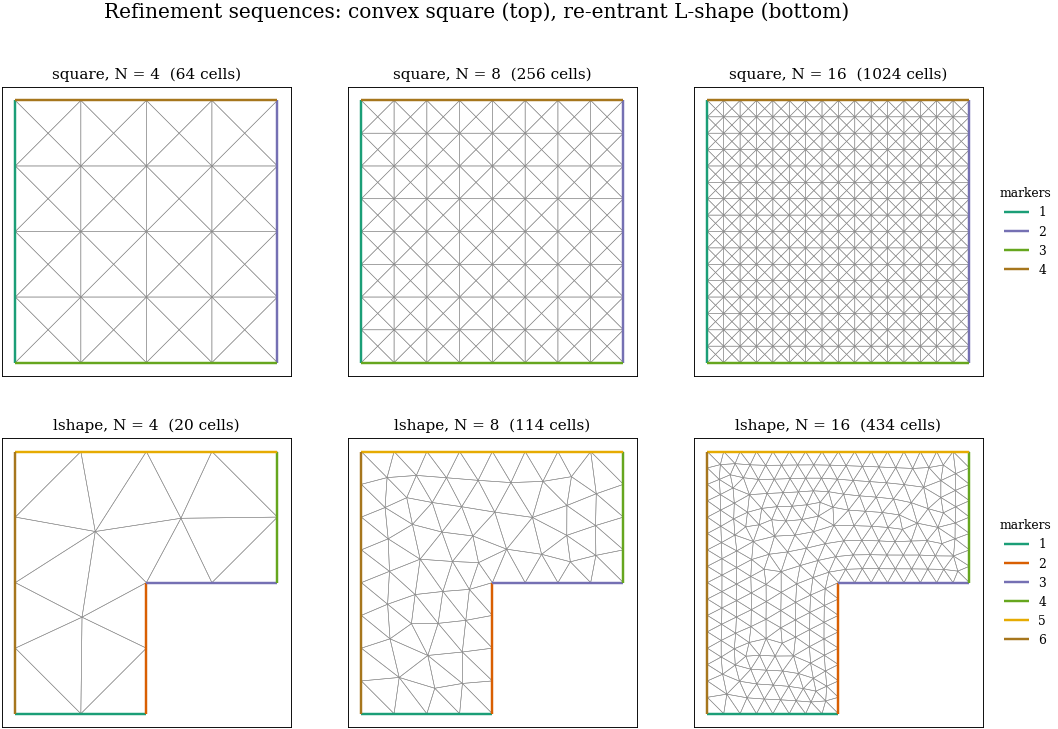

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.6))

for row, (name, builder) in enumerate(DOMAINS.items()):
    for col, N in enumerate((4, 8, 16)):
        ax = axes[row, col]
        mesh = builder(N)
        # `interior_kw` is forwarded to a matplotlib PolyCollection (one polygon
        # per cell), so it wants `edgecolors`, not `color`: passing `color` sets
        # the *face* colour too and paints the domain solid.  `boundary_kw` goes
        # to a LineCollection, one per boundary marker.
        triplot(mesh, axes=ax,
                interior_kw={"linewidths": 0.35, "edgecolors": "0.55"},
                boundary_kw={"linewidths": 1.6})
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{name}, N = {N}  ({mesh.num_cells()} cells)", fontsize=10)

# One legend for the whole figure: it maps colours to boundary markers.
axes[0, 2].legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
                  fontsize=8, title="markers", title_fontsize=8, frameon=False)
axes[1, 2].legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
                  fontsize=8, title="markers", title_fontsize=8, frameon=False)
fig.suptitle("Refinement sequences: convex square (top), re-entrant L-shape (bottom)")
fig.savefig(FIGDIR / "meshes.pdf")
plt.show()

The bottom row shows the essential difference between the two domains. Netgen grades
the L-shape mesh automatically, but no amount of *uniform* refinement fixes the
$r^{2/3}$ behaviour at the re-entrant corner — that is a property of the continuous
solution, and it is precisely what makes the L-shape a discriminating test.

<a id="3"></a>
## 3. Velocity fields (winds)

A wind is nothing more than a UFL expression in the mesh coordinates. It is *not* a
`Function`: leaving it symbolic means the discontinuity of the Heaviside shear is
resolved by the quadrature rule rather than smeared by an interpolation step.

Every wind below is **divergence-free**, which the derivation of formulation (A)
in Section 1.1 requires:

| Tag | $u$ | Regularity | $\nabla\!\cdot u$ |
|:--|:--|:--|:--|
| `W0` | $(0,0)$ | $C^\infty$ | $0$ — self-adjoint baseline |
| `W1` | $(1,0)$ | $C^\infty$ | $0$ — uniform translation |
| `W2` | $(\sin y,\ \sin x)$ | $C^\infty$ | $0$ — smooth, non-gradient |
| `W3` | $(\operatorname{sign}(y-\tfrac{L}{2}),\ 0)$ | $L^\infty\setminus W^{1,\infty}$ | $0$ — Heaviside shear |

`W3` is the case of interest: $u$ is bounded but not Lipschitz, so the coefficient of
the first-order term in the operator is merely measurable. Note that $\partial_x u_x = 0$
for *any* profile $u=(f(y),0)$, so the shear is exactly solenoidal despite the jump.

In [4]:
@dataclass(frozen=True)
class Wind:
    """A named background velocity field, built lazily on a given mesh."""
    key: str
    tex: str                  # LaTeX label, for figure titles
    note: str                 # one-line description
    _build: Callable          # (mesh, L) -> UFL vector expression or None

    def __call__(self, mesh, L=L_DOMAIN):
        return self._build(mesh, L)


def _zero(mesh, L):
    # `None` is the sentinel for "no advection term at all".  Returning a zero
    # vector would work too, but assembling nothing is both faster and keeps the
    # resulting matrix exactly symmetric.
    return None


def _uniform(mesh, L):
    # Constant() wraps a number as a UFL constant so it can be changed without
    # recompiling the form.
    return as_vector([Constant(1.0), Constant(0.0)])


def _cellular(mesh, L):
    # SpatialCoordinate(mesh) is the UFL symbol for x; `sin` here is UFL's sin,
    # not numpy's, so the expression stays symbolic and differentiable.
    x, y = SpatialCoordinate(mesh)
    return as_vector([sin(y), sin(x)])


def _shear(mesh, L):
    # conditional(gt(a, b), p, q) is UFL's ternary operator; it is evaluated at
    # each quadrature point, so the jump is captured exactly at the element level
    # rather than being interpolated into a finite element space.
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(y, Constant(L / 2)), 1.0, -1.0), Constant(0.0)])


WINDS = {
    "W0": Wind("W0", r"$u=(0,0)$", "self-adjoint baseline", _zero),
    "W1": Wind("W1", r"$u=(1,0)$", "uniform translation", _uniform),
    "W2": Wind("W2", r"$u=(\sin y,\,\sin x)$", "smooth cellular", _cellular),
    "W3": Wind("W3", r"$u=(\mathrm{sign}(y-L/2),\,0)$", "Heaviside shear", _shear),
}

To visualise a symbolic wind we need to give it a home in some finite element space.
Two complementary views are used throughout:

* the horizontal component $u_x$ interpolated into **$\mathrm{DG}_0$** and drawn with
  `tripcolor` — piecewise constants render the jump of `W3` as a genuine
  discontinuity, with no smoothing;
* direction arrows sampled on a **regular grid** with `PointEvaluator`, which returns
  `NaN` outside the domain and so handles the L-shape's notch for free.

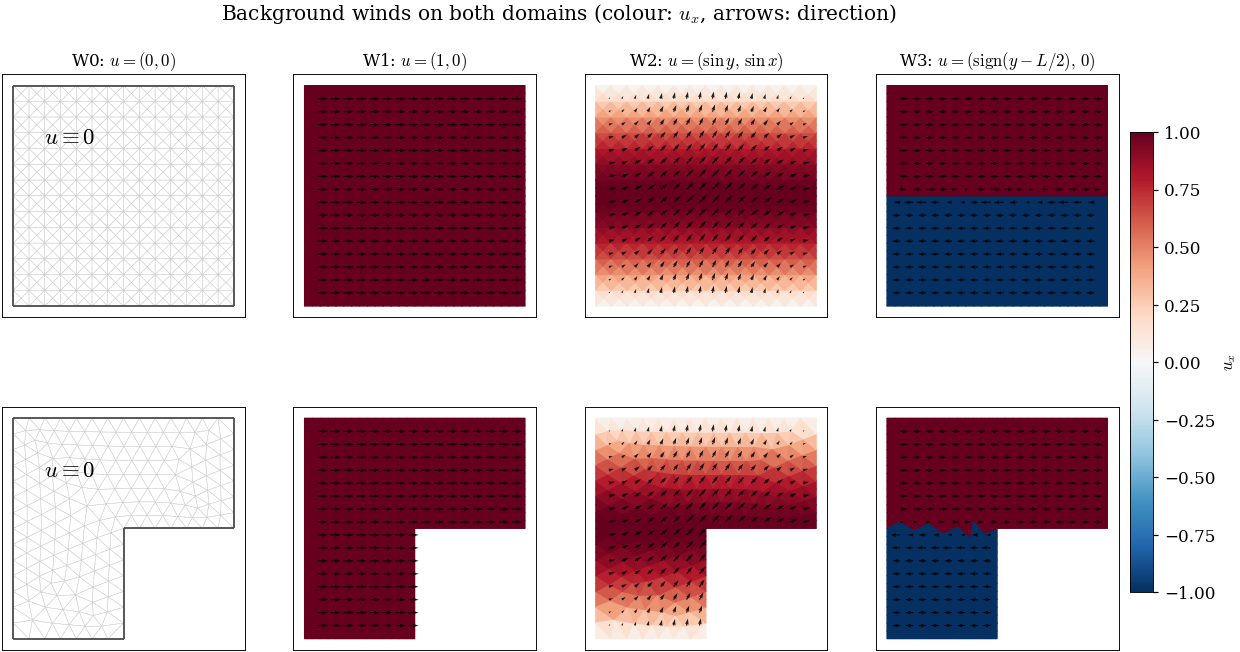

In [5]:
def sample_grid(f, mesh, n=18, pad=0.06):
    """Evaluate a vector `Function` on a regular n x n grid over the mesh bbox.

    `PointEvaluator` is the supported replacement for the deprecated
    `Function.at`.  With `missing_points_behaviour="ignore"` the points that fall
    outside the domain -- the whole notch of the L-shape -- come back as NaN,
    which matplotlib simply does not draw.
    """
    coords = mesh.coordinates.dat.data_ro
    (x0, y0), (x1, y1) = coords.min(axis=0), coords.max(axis=0)
    dx, dy = pad * (x1 - x0), pad * (y1 - y0)
    X, Y = np.meshgrid(np.linspace(x0 + dx, x1 - dx, n),
                       np.linspace(y0 + dy, y1 - dy, n))
    pts = np.column_stack([X.ravel(), Y.ravel()])
    # `tolerance` is measured in *reference cell* coordinates and defaults to
    # the mesh's own value (0.5 here), which is loose enough to snap points that
    # sit well outside the domain into a nearby boundary cell -- arrows would
    # then leak across the L-shape's notch.  A tight tolerance fixes it.
    vals = np.asarray(
        PointEvaluator(mesh, pts, missing_points_behaviour="ignore",
                       tolerance=1e-6).evaluate(f))
    return X, Y, vals[:, 0].reshape(X.shape), vals[:, 1].reshape(X.shape)


def as_cg_vector(expr, mesh, degree=1):
    """Project a UFL vector expression into [CG_degree]^2, for plotting only."""
    return Function(VectorFunctionSpace(mesh, "CG", degree)).project(expr)


def plot_wind(ax, u, mesh, n=16, cmap="RdBu_r"):
    """Colour = horizontal component; arrows = direction and relative magnitude."""
    if u is None:
        # `boundary_kw["colors"]` is zipped against the list of markers, so a
        # single colour string would draw only the first marker and silently
        # drop the rest.  One entry per marker.
        markers = mesh.exterior_facets.unique_markers
        triplot(mesh, axes=ax,
                interior_kw={"linewidths": 0.25, "edgecolors": "0.8"},
                boundary_kw={"linewidths": 1.2, "colors": ["0.3"] * len(markers)})
        # (0.5, 0.5) in axes coordinates is the re-entrant corner of the
        # L-shape, so the label goes into the upper-left arm instead.
        ax.text(0.28, 0.74, r"$u\equiv 0$", ha="center", va="center",
                transform=ax.transAxes, fontsize=15)
        handle = None
    else:
        # DG0 interpolation: one constant per cell, so a jump stays a jump.
        ux = Function(FunctionSpace(mesh, "DG", 0)).interpolate(u[0])
        lim = float(np.abs(ux.dat.data_ro).max()) or 1.0
        handle = tripcolor(ux, axes=ax, cmap=cmap, vmin=-lim, vmax=lim)
        X, Y, U, V = sample_grid(as_cg_vector(u, mesh), mesh, n=n)
        # `angles="xy", scale_units="xy"` measures arrow length in *data* units,
        # so a vector of maximal magnitude spans 0.8 of the sampling spacing and
        # no arrow can spill across the L-shape's notch.
        speed = np.nanmax(np.hypot(U, V)) or 1.0
        step = float(X[0, 1] - X[0, 0])
        ax.quiver(X, Y, U, V, color="k", angles="xy", scale_units="xy",
                  scale=speed / (0.8 * step), width=0.005, alpha=0.85)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    return handle


fig, axes = plt.subplots(2, 4, figsize=(13.5, 7.2))
for col, key in enumerate(("W0", "W1", "W2", "W3")):
    for row, builder in enumerate((square_mesh, lshape_mesh)):
        mesh = builder(14)
        h = plot_wind(axes[row, col], WINDS[key](mesh), mesh)
        if row == 0:
            axes[row, col].set_title(f"{key}: {WINDS[key].tex}", fontsize=11)
fig.colorbar(h, ax=axes, fraction=0.02, pad=0.01, label=r"$u_x$")
fig.suptitle("Background winds on both domains (colour: $u_x$, arrows: direction)", y=0.95)
fig.savefig(FIGDIR / "winds.pdf")
plt.show()

The `W3` panels show the discontinuity crisply: the two half-domains are advected in
opposite directions and the shear layer sits on the line $y = \pi/2$. Two features of
these pictures are worth naming before they resurface in the results.

**The shear line is mesh-aligned on the square and not on the L-shape.** With $N$ even,
$y=\pi/2$ is a grid line of the criss-cross mesh; on the Netgen mesh the jump cuts
through elements, and the $\mathrm{DG}_0$ picture is visibly ragged. The quadrature
still sees the exact discontinuity — nothing is smoothed — but the *element* cannot
align with it, which is the realistic situation.

**`W1` and `W3` are not tangential to the boundary.** On the square,
$u\cdot n = \pm 1$ on $x=0$ and $x=\pi$: the wind blows *through* the vertical walls.
That is what the problem statement asks for and it is a perfectly well-posed operator,
but it does give the discrete problem an inflow/outflow character, and the adjoint
accordingly picks up a boundary term $\oint (u\cdot n)\,A\,z$. Section 8.6 shows that
term as a boundary layer in the left eigenvectors. If a strictly tangential shear is
wanted instead, take a stream function that vanishes on $\partial\Omega$ — for example
$\psi = \sin(x)\,\bigl(|y-\tfrac{\pi}{2}| - \tfrac{\pi}{2}\bigr)$, whose curl is
divergence-free, tangential, and still discontinuous across $y=\pi/2$.

On the L-shape the shear line runs straight into the re-entrant corner, so the two
sources of irregularity — the corner and the jump in $u$ — meet at a point. That is
deliberate: it is the hardest configuration this laboratory can produce.

<a id="4"></a>
## 4. Function spaces and weak formulations

### 4.1 The discrete de Rham complexes

In two dimensions the relevant complex is

$$
\mathbb{R}\;\hookrightarrow\; H^1(\Omega)\;\xrightarrow{\ \nabla\ }\;H(\mathrm{curl};\Omega)\;\xrightarrow{\ \nabla\times\ }\;L^2(\Omega)\;\to\;0 ,
$$

with 0-forms in $H^1$, 1-forms in $H(\mathrm{curl})$ and 2-forms in $L^2$. A
discretisation is a **subcomplex** when the discrete spaces reproduce this
structure exactly, i.e. $\nabla V_h^0 \subseteq V_h^1$. Firedrake offers the two
classical simplicial families:

$$
\text{trimmed:}\quad \mathrm{CG}_r \xrightarrow{\ \nabla\ } \mathrm{N1curl}_r \xrightarrow{\ \nabla\times\ } \mathrm{DG}_{r-1},
\qquad\qquad
\text{full:}\quad \mathrm{CG}_{r+1} \xrightarrow{\ \nabla\ } \mathrm{N2curl}_r \xrightarrow{\ \nabla\times\ } \mathrm{DG}_{r-1}.
$$

`N1curl` is Nédélec of the **first kind** (the trimmed / Whitney family: it contains
$\mathcal{P}_{r-1}^2$ plus a rotational bubble, and its curl is a *full* polynomial
space). `N2curl` is Nédélec of the **second kind**: it contains all of
$\mathcal{P}_r^2$, so it approximates the field itself one order better, but its curl
is no richer — which is why it must be paired with $\mathrm{CG}_{r+1}$ to keep the
complex exact.

The multiplier $p$ that enforces $\nabla\!\cdot B = 0$ is a **discrete 0-form**: it
enters the weak form only through $\nabla p$, which lands in the edge space by
construction. Pairing the multiplier with the space *one step to the left* in the
complex is exactly what makes the saddle-point system inf-sup stable.

In [6]:
def space_A(mesh, degree=1):
    r"""Formulation A: the potential $A$ is a discrete **0-form**, $A_h \in \mathrm{CG}_r$.

    No multiplier space appears here.  The gauge constraint $\int_\Omega A = 0$ lives
    in $\mathbb{R}$, and is attached to the assembled matrix in Section 5.3 -- see
    the note there on why an "R" block cannot be carried in the mixed space itself.
    """
    return FunctionSpace(mesh, "CG", degree)


def space_BN1(mesh, degree=1):
    r"""Formulation B, trimmed: $\mathrm{N1curl}_r \times \mathrm{CG}_r$.

    In Firedrake `V * Q` builds the MixedFunctionSpace; `TrialFunctions(W)` then
    splits a trial function into its components in one call.
    """
    return FunctionSpace(mesh, "N1curl", degree) * FunctionSpace(mesh, "CG", degree)


def space_BN2(mesh, degree=1):
    r"""Formulation B, full: $\mathrm{N2curl}_r \times \mathrm{CG}_{r+1}$.

    The multiplier degree is bumped by one so that
    $\nabla(\mathrm{CG}_{r+1}) \subseteq \mathrm{N2curl}_r$, i.e. so that the pair
    is still a de Rham subcomplex.  Using CG_r here instead would silently break
    exactness and is a classic source of spurious modes.
    """
    return FunctionSpace(mesh, "N2curl", degree) * FunctionSpace(mesh, "CG", degree + 1)


SPACES = {"A(CG)": space_A, "B(N1)": space_BN1, "B(N2)": space_BN2}

### 4.2 The B formulations

In two dimensions `curl` acts on a vector field and returns a **scalar**,
$\nabla\times v = \partial_x v_1 \! - \partial_y v_0$, and the cross product of two
planar vectors is the scalar $z$-component of the 3D one. UFL has no built-in symbol
for the latter, so we supply it. The ordering matters: the induction term is
$\nabla\times(u\times B)$, and after integration by parts against a test function $w$
it appears as $(v\times u,\ \nabla\times w)$, i.e. with the *field first*.

The weak problem is: find $(v,p) \in V_h \times Q_h$ and $\lambda$ with

$$
\varepsilon\,(\nabla\times v,\ \nabla\times w) \;+\; (v\times u,\ \nabla\times w)\;-\;(\nabla p,\ w) \;=\; \lambda\,(v,\,w)
\qquad \forall\, w \in V_h,
$$
$$
(v,\ \nabla q) \;=\; 0 \qquad \forall\, q \in Q_h .
$$

The second line is the discrete divergence constraint: it says $v$ is $L^2$-orthogonal
to all discrete gradients. On a simply connected domain with no harmonic fields this
removes the entire $\dim Q_h$-dimensional kernel of the curl, leaving only the
"physical" modes.

In [7]:
def cross2d(a, b):
    r"""Scalar 2D cross product $(a\times b)_z = a_0 b_1 - a_1 b_0$.

    Antisymmetric, so the argument order is load-bearing: the induction term needs
    cross2d(v, u), i.e. $v\times u$.
    """
    return a[0] * b[1] - a[1] * b[0]


def forms_B(W, u=None, eps=Constant(1.0)):
    r"""Bilinear forms of the mixed B-formulation on the mixed space `W`.

    Returns (a, m) with $a$ the operator form and $m$ the mass form.  Note that
    $m$ involves **only** the field: the multiplier block of the mass matrix is
    identically zero.  That is the structural reason the pencil is singular.
    """
    v, p = TrialFunctions(W)      # unpack the mixed trial function
    w, q = TestFunctions(W)       # ... and the mixed test function

    # 1. Diffusion.  In 2D curl(v) is scalar, so this is a scalar L2 product.
    a = eps * inner(curl(v), curl(w)) * dx

    # 2. Induction.  Skipped entirely when u is None, which keeps the W0 pencil
    #    exactly symmetric down to the last bit.
    if u is not None:
        a += inner(cross2d(v, u), curl(w)) * dx

    # 3. The saddle-point coupling.  The two off-diagonal blocks carry opposite
    #    signs so that the whole operator stays symmetric when u is None.
    a += (-inner(grad(p), w) + inner(v, grad(q))) * dx

    m = inner(v, w) * dx
    return a, m


def bcs_B(W):
    r"""Essential boundary conditions for the B-formulations.

    * `DirichletBC(W.sub(0), (0,0), "on_boundary")` on an H(curl) space constrains
      the **tangential trace** $v\times n$, not the full vector: the edge degrees
      of freedom of N1curl/N2curl *are* tangential moments, so setting them to
      zero imposes exactly $B\times n = 0$ and nothing more.  This is the discrete
      statement of the wall condition from Section 1.2.

    * `DirichletBC(W.sub(1), 0, "on_boundary")` puts the multiplier in
      $\mathrm{CG}\cap H^1_0$.  This is not a physical condition on $p$; it is what
      makes the discrete gradients $\nabla Q_h$ a subspace of $H_0(\mathrm{curl})$,
      so that the constraint $(v,\nabla q)=0$ tests against the right space.  Drop
      it and the constraint over-determines $v$ near the boundary.
    """
    return [DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary"),
            DirichletBC(W.sub(1), Constant(0.0), "on_boundary")]

### 4.3 The A formulation

Multiplying $-\varepsilon\Delta A + u\cdot\nabla A = \lambda A$ by $z \in H^1(\Omega)$ and
integrating by parts once gives

$$
\varepsilon\,(\nabla A,\ \nabla z) \;+\; (u\cdot\nabla A,\ z) \;-\; \underbrace{\varepsilon \int_{\partial\Omega} (\partial_n A)\, z}_{\;=\,0\ \text{by the wall condition}} \;=\; \lambda\,(A,\,z).
$$

**The boundary condition is imposed by omission.** There is no `DirichletBC` in this
formulation at all: $\partial_n A = 0$ is *natural*, and dropping the boundary integral
is precisely how it is enforced. What has to be supplied instead is the gauge, because
$A$ and $A + c$ describe the same magnetic field:

$$
\int_\Omega A \;=\; 0 .
$$

Without it, the constant function is a genuine eigenvector at $\lambda = 0$ and the
stiffness matrix is singular. Section 5.3 attaches the constraint as a rank-one border.

In [8]:
def forms_A(V, u=None, eps=Constant(1.0)):
    r"""Bilinear forms of the potential formulation on the scalar space `V`.

    `TrialFunction` / `TestFunction` (singular) because `V` is not mixed.  The
    advection term uses `dot(u, grad(A))`, which is the convective derivative
    $u\cdot\nabla A$; it is *not* integrated by parts, so no boundary term is
    generated and the discontinuity of `u` is only ever seen by the quadrature.
    """
    A, z = TrialFunction(V), TestFunction(V)

    a = eps * inner(grad(A), grad(z)) * dx           # diffusion (symmetric)
    if u is not None:
        a += inner(dot(u, grad(A)), z) * dx          # advection (non-symmetric)

    m = inner(A, z) * dx
    return a, m


def bcs_A(V):
    """No essential conditions: see the discussion above -- the wall condition on
    this formulation is natural, and the gauge is applied to the matrix."""
    return []


FORMS = {"A(CG)": forms_A, "B(N1)": forms_B, "B(N2)": forms_B}

<a id="5"></a>
## 5. Assembling the matrix pencil

`assemble(a)` returns a Firedrake `Matrix`; its `.petscmat` attribute is the underlying
`PETSc.Mat`, which is what SLEPc consumes. Two details deserve comment.

### 5.1 Boundary conditions and the mass matrix

Firedrake applies a `DirichletBC` to a matrix by zeroing the constrained rows and
columns and placing a value on the diagonal — `1` by default. If we did that to **both**
$A$ and $M$, every boundary degree of freedom would contribute a spurious eigenvalue
$\lambda = 1$, sitting right in the middle of the spectrum we care about.

The fix is the `weight` argument:

```python
A = assemble(a, bcs=bcs).petscmat                 # diagonal 1 on constrained rows
M = assemble(m, bcs=bcs, weight=0.0).petscmat     # diagonal 0 on constrained rows
```

so each boundary row reads $1\cdot x_i = \lambda \cdot 0 \cdot x_i$, i.e.
$\lambda = \infty$. The boundary modes are pushed out to infinity, where the multiplier
modes already are, and a single filter removes both.

### 5.2 Why $M$ is singular, and why that is fine

The mass form $m = (v,w)\,dx$ touches only the field block, so

$$
M \;=\; \begin{pmatrix} M_v & 0 \\ 0 & 0\end{pmatrix},
$$

and $\operatorname{rank} M = \dim V_h < \dim W_h$. The pencil $(A, M)$ therefore has
$\dim Q_h$ eigenvalues at infinity by construction. This rules out any method that
factorises $M$; it does **not** rule out shift-and-invert, which factorises
$A - \tau M$ instead.

### 5.3 The gauge constraint as a rank-one border

For formulation A we want to solve, with $g_i = \int_\Omega \phi_i$,

$$
\begin{pmatrix} K & -g \\ -g^{\mathsf T} & 0 \end{pmatrix}
\begin{pmatrix} a \\ t \end{pmatrix}
\;=\;\lambda
\begin{pmatrix} M & 0 \\ 0 & 0 \end{pmatrix}
\begin{pmatrix} a \\ t \end{pmatrix},
$$

the multiplier $t\in\mathbb{R}$ enforcing $g^{\mathsf T}a = \int_\Omega A_h = 0$. The
natural Firedrake spelling would be a mixed space `CG * R`, and it does assemble — but
only as a `MATNEST`, which cannot be converted to AIJ (`PETSC_ERR_SUP`) and cannot be
factorised by MUMPS. Since the constraint is only a rank-one border, we attach it to the
assembled blocks directly. Six lines of `scipy.sparse` do the job, and the negative
sign on both off-diagonal blocks keeps $A$ symmetric when $u = 0$.

In [9]:
def to_scipy(mat):
    """PETSc AIJ -> scipy CSR (serial).  `getValuesCSR` hands back the raw arrays."""
    indptr, indices, data = mat.getValuesCSR()
    return sp.csr_matrix((data, indices, indptr), shape=mat.getSize())


def to_petsc(S):
    """scipy CSR -> PETSc AIJ.  PETSc requires sorted column indices per row."""
    S = S.tocsr(); S.sort_indices()
    return PETSc.Mat().createAIJWithArrays(
        S.shape, (S.indptr.astype(PETSc.IntType),
                  S.indices.astype(PETSc.IntType), S.data))


def border_with_gauge(K, M, g):
    r"""Return the bordered pencil enforcing $g^{\mathsf T}a = 0$.

    `sp.bmat` with `None` blocks builds the zero blocks for us, so the whole
    construction is one call per matrix.
    """
    col = sp.csr_matrix(-np.asarray(g).reshape(-1, 1))          # the -g column
    A_b = sp.bmat([[to_scipy(K), col], [col.T, None]], format="csr")
    M_b = sp.bmat([[to_scipy(M), None], [None, sp.csr_matrix((1, 1))]], format="csr")
    return to_petsc(A_b), to_petsc(M_b)


@dataclass
class Pencil:
    """An assembled generalised eigenproblem $Ax = \\lambda Mx$ plus its provenance."""
    A: PETSc.Mat
    M: PETSc.Mat
    V: object            # the FunctionSpace the eigenvectors live in
    form: str
    ndof: int            # dofs of V, i.e. excluding any border row

    @property
    def size(self):
        return self.A.getSize()[0]

    def to_function(self, vec):
        """Wrap a PETSc Vec as a Firedrake Function on `V`.

        `dat.vec_wo` exposes the Function's own Vec in write-only mode; taking the
        leading `getLocalSize()` entries silently discards the gauge multiplier of
        the bordered A-pencil, which is exactly what we want to plot.
        """
        f = Function(self.V)
        with f.dat.vec_wo as fv:
            fv.setArray(vec.getArray(readonly=True)[:fv.getLocalSize()])
        return f

    def transposed(self):
        """The pencil $(A^{\\mathsf T}, M^{\\mathsf T})$ -- see Section 6.3.

        Careful: `PETSc.Mat.transpose()` called with no output argument
        transposes **in place** and hands back the same object, which would
        quietly corrupt the pencil we were given.  Copy first.
        """
        At, Mt = self.A.copy(), self.M.copy()
        At.transpose(); Mt.transpose()
        return Pencil(At, Mt, self.V, self.form + "^T", self.ndof)


def build_pencil(mesh, form="B(N1)", u=None, Rm=1.0, degree=1):
    """Assemble (A, M) for any of the three formulations."""
    eps = Constant(1.0 / Rm)

    if form == "A(CG)":
        V = space_A(mesh, degree)
        a, m = forms_A(V, u=u, eps=eps)
        # bcs_A(V) is empty: the wall condition here is natural (Section 4.3).
        K, M = assemble(a).petscmat, assemble(m).petscmat
        # g_i = \int phi_i : assembling the linear form `z*dx` gives exactly that.
        g = np.asarray(assemble(TestFunction(V) * dx).dat.data_ro).copy()
        A_b, M_b = border_with_gauge(K, M, g)
        return Pencil(A_b, M_b, V, form, V.dim())

    W = SPACES[form](mesh, degree)
    a, m = forms_B(W, u=u, eps=eps)
    bcs = bcs_B(W)
    A = assemble(a, bcs=bcs).petscmat
    M = assemble(m, bcs=bcs, weight=0.0).petscmat     # boundary modes -> infinity
    return Pencil(A, M, W, form, W.dim())

<a id="6"></a>
## 6. The solver: shift-and-invert with SLEPc

### 6.1 Why the obvious thing fails

A Krylov method applied to $Ax = \lambda M x$ needs to apply *some* operator repeatedly.
The default choice, $M^{-1}A$, is unavailable: $M$ is singular. The default *ordering*
is also wrong — Krylov methods converge first to the extremal part of the spectrum,
whereas the physically meaningful modes here are the ones of **smallest** magnitude,
the slowest-decaying fields.

**Shift-and-invert** solves both problems at once. Fix a shift $\tau$ and replace the
pencil by

$$
(A - \tau M)^{-1} M\, x \;=\; \theta\, x ,
\qquad\qquad
\theta \;=\; \frac{1}{\lambda - \tau} .
$$

Eigenvalues near $\tau$ become the extremal $\theta$'s and converge first; eigenvalues at
infinity map to $\theta = 0$ and converge *last*, or not at all. The singularity of $M$
has been turned from an obstacle into a filter.

### 6.2 Configuring the transformation

Three requirements, and the option that meets each:

| Requirement | Option |
|:--|:--|
| Reciprocal shift-and-invert spectral transformation | `st_type: sinvert` |
| A shift $\tau \neq 0$ so that $A - \tau M$ is strictly invertible and lies near the modes we want | `eps_target: tau` |
| A **direct** solve for $A-\tau M$ — the shifted matrix is a saddle-point system, indefinite and with a zero block, so no Krylov/ILU combination is dependable | `st_ksp_type: preonly`, `st_pc_type: lu`, `st_pc_factor_mat_solver_type: mumps` |

On the choice of $\tau$: it must avoid the spectrum, and it should sit just below the
first eigenvalue. Since the leading decay rate scales as $\lambda_1 \approx \nu_1/R_m$
with $\nu_1 = O(1)$ the first Laplace/Maxwell eigenvalue, the default below is
$\tau = 0.95/R_m$ — near the interesting modes, and deliberately *off* $1/R_m$, which is
an exact eigenvalue on the square (Section 8.3).

`st_mat_mumps_icntl_14: 500` raises MUMPS' working-space allowance to 500%. Saddle-point
factorisations need heavy pivoting, and without this the factorisation aborts with
`INFOG(1) = -9` on all but the smallest meshes.

In [10]:
#: PETSc/SLEPc options, in the same dictionary form used by Firedrake solvers.
EPS_OPTS = {
    # --- the eigenproblem ---------------------------------------------------
    "eps_gen_non_hermitian": None,   # generalised, non-Hermitian pencil (GNHEP)
    "eps_type": "krylovschur",       # thick-restart Krylov-Schur
    "eps_target_magnitude": None,    # order by |lambda - tau|
    "eps_tol": 1e-11,
    "eps_max_it": 2000,
    # --- the spectral transformation ---------------------------------------
    "st_type": "sinvert",            # (A - tau M)^{-1} M
    # --- the inner linear solve --------------------------------------------
    "st_ksp_type": "preonly",        # no Krylov wrapper: the LU *is* the solve
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500,    # working-space headroom for pivoting
}

_prefix_counter = itertools.count()


def solve_pencil(pencil, tau=0.95, nev=24, **overrides):
    """Run one SLEPc EPS solve on an assembled pencil and return the solver.

    The options above are pushed into the global PETSc options database under a
    unique prefix, which is how PETSc-style configuration reaches an object that
    Firedrake did not create for us.  The keys are removed afterwards so that
    repeated calls in a notebook never leak options into one another.
    """
    opts = dict(EPS_OPTS, eps_target=tau, **overrides)
    prefix = f"mhd{next(_prefix_counter)}_"
    db = PETSc.Options()
    for key, value in opts.items():
        db[prefix + key] = value

    eps = SLEPc.EPS().create(comm=pencil.A.getComm())
    eps.setOptionsPrefix(prefix)
    eps.setOperators(pencil.A, pencil.M)     # the generalised pair (A, M)
    eps.setDimensions(nev=nev)               # how many eigenpairs to request
    eps.setFromOptions()                     # reads everything set above
    eps.solve()

    for key in opts:
        db.delValue(prefix + key)
    return eps


def harvest(eps, inf_tol=1e8):
    """Converged **finite** eigenvalues as (slepc_index, value), sorted by Re.

    The infinite eigenvalues of Section 5.2 come back either as `inf`/`nan` or as
    very large finite numbers, depending on how the Krylov-Schur restart happened
    to hit them; one threshold catches both.
    """
    out = [(i, complex(eps.getEigenvalue(i))) for i in range(eps.getConverged())]
    out = [(i, z) for i, z in out if np.isfinite(z) and abs(z) < inf_tol]
    return sorted(out, key=lambda pair: (pair[1].real, abs(pair[1].imag)))

### 6.3 Left eigenvectors and non-normality

For $u \neq 0$ the operator is not self-adjoint, so the **left** eigenvector
$y$ — defined by $y^{*}A = \lambda\, y^{*}M$ — is no longer the right one. It matters:
the sensitivity of an eigenvalue to perturbation is governed by the angle between $x$
and $y$, through the condition number

$$
\kappa(\lambda)\;=\;\frac{\lVert x\rVert_{M}\,\lVert y\rVert_{M}}{\lvert\, y^{*}M x\,\rvert}\;\ge\;1 ,
\qquad \lVert z\rVert_{M}^2 = z^{*}M z ,
$$

with equality exactly in the normal case. **The choice of norm is not cosmetic.** Taken
in the Euclidean coefficient norm, $\kappa$ grows without bound under refinement — like
$h^{-2}$ for the nodal formulation — and says nothing about the operator; taken in the
mass-matrix norm, which is the discrete $L^2$ norm of the eigen*function*, it converges
to a mesh-independent number. Section 8.6 shows both facts numerically.

Two caveats worth stating once. First, $\kappa$ as written is meaningful only for a
**simple** eigenvalue: on a degenerate eigenspace the two solves may return different
bases and the overlap $y^{*}Mx$ is then arbitrary. Second, $M$ is the mass matrix of
whichever variable the formulation carries, so $\kappa$ measures an angle in $L^2(A)$
for the potential formulation and in $L^2(B)$ for the field formulations. In practice
the two track each other closely wherever both are resolved, but exact agreement between
them is not something to expect.

SLEPc can compute both sides in one pass with `-eps_two_sided`, but its two-sided
Krylov–Schur is fragile on pencils with a large infinite eigenvalue block: it aborts
with *"invalid permutation due to a 2×2 block"* on exactly the saddle-point systems we
have here. We use the robust route instead. Taking the conjugate transpose of the
defining relation and using that our matrices are real,

$$
y^{*}A = \lambda\,y^{*}M
\qquad\Longleftrightarrow\qquad
A^{\mathsf T} y \;=\; \bar\lambda\; M^{\mathsf T} y ,
$$

so **the left eigenvectors of $(A,M)$ are the right eigenvectors of
$(A^{\mathsf T},M^{\mathsf T})$**, at the conjugated eigenvalue. Two ordinary one-sided
solves, and the eigenvalues of the two runs agree to machine precision — which is itself
a useful consistency check.

In [11]:
def complex_vector(eps, i, pencil):
    """The i-th eigenvector as (complex coefficient array, Re Function, Im Function).

    PETSc here is built for *real* scalars, so SLEPc returns a complex eigenvector
    as a pair of real Vecs.  We keep both views: the numpy array for algebra, the
    Firedrake Functions for plotting.
    """
    vr, vi = pencil.A.createVecRight(), pencil.A.createVecRight()
    eps.getEigenvector(i, vr, vi)
    z = np.asarray(vr.getArray()).copy() + 1j * np.asarray(vi.getArray()).copy()
    return z, pencil.to_function(vr), pencil.to_function(vi)


@dataclass
class Mode:
    """One eigenpair: value, right eigenfunction, and (if computed) its adjoint."""
    value: complex
    right: tuple                       # (Re, Im) Firedrake Functions
    left: Optional[tuple] = None
    condition: Optional[float] = None  # kappa(lambda); None when not computed

    @property
    def is_complex(self):
        return abs(self.value.imag) > 1e-10 * max(1.0, abs(self.value.real))

<a id="7"></a>
## 7. The execution loop

Everything so far is assembled into a single entry point. Choosing a **domain**, a
**formulation** and a **wind** is choosing three dictionary keys; the rest of the
signature is the physics ($R_m$, polynomial degree, mesh level) and the solver
($\tau$, how many eigenpairs).

In [12]:
@dataclass
class Spectrum:
    """The result of one experiment: modes, the pencil they came from, and metadata."""
    modes: list
    pencil: Pencil
    mesh: object
    wind: Optional[object]
    meta: dict

    @property
    def values(self):
        return np.array([m.value for m in self.modes])

    def frame(self):
        """A tidy pandas view of the spectrum."""
        return pd.DataFrame({
            "n": np.arange(len(self.modes)),
            "Re lambda": [m.value.real for m in self.modes],
            "Im lambda": [m.value.imag for m in self.modes],
            "kappa": [m.condition for m in self.modes],
        })


def solve_induction(domain="square", form="B(N1)", wind="W0", *, N=16, degree=1,
                    Rm=1.0, tau=None, n_eigs=6, nev=24, L=L_DOMAIN,
                    left=None, mesh=None):
    r"""Solve the induction eigenproblem for one (domain, formulation, wind).

    Parameters
    ----------
    domain : {"square", "lshape"}
    form   : {"A(CG)", "B(N1)", "B(N2)"}
    wind   : {"W0", "W1", "W2", "W3"}
    N      : mesh level -- cells per unit length (square) or 1/maxh (L-shape)
    Rm     : magnetic Reynolds number; the diffusivity is eps = 1/Rm
    tau    : shift for the spectral transformation.  Defaults to 0.95/Rm, which
             tracks the leading decay rate as Rm varies.
    left   : compute left eigenvectors and condition numbers.  Defaults to True
             whenever the wind is non-zero, i.e. whenever they can differ from
             the right ones.
    """
    tau = 0.95 / Rm if tau is None else tau
    mesh = DOMAINS[domain](N, L) if mesh is None else mesh
    u = WINDS[wind](mesh, L)

    pencil = build_pencil(mesh, form=form, u=u, Rm=Rm, degree=degree)
    eps = solve_pencil(pencil, tau=tau, nev=nev)
    found = harvest(eps)[:n_eigs]

    want_left = (u is not None) if left is None else left
    if want_left:
        adjoint = pencil.transposed()
        adj_eps = solve_pencil(adjoint, tau=tau, nev=nev)
        adj_found = harvest(adj_eps)
        M_sp = to_scipy(pencil.M)

    modes = []
    for index, lam in found:
        x, xr, xi = complex_vector(eps, index, pencil)
        mode = Mode(lam, (xr, xi))
        if want_left and adj_found:
            # pair by eigenvalue: the adjoint run sees conj(lambda)
            j = min(adj_found, key=lambda pair: abs(pair[1] - np.conj(lam)))[0]
            y, yr, yi = complex_vector(adj_eps, j, adjoint)
            # kappa in the M-norm: mesh-independent, and exactly 1 whenever the
            # eigenvalue is simple and the operator normal.  M is only positive
            # *semi*-definite -- the multiplier block carries no mass -- so these
            # are the L2 norms of the field part alone, which is what we want.
            overlap = abs(np.vdot(y, M_sp @ x))
            x_M = np.sqrt(abs(np.vdot(x, M_sp @ x)))
            y_M = np.sqrt(abs(np.vdot(y, M_sp @ y)))
            mode.left = (yr, yi)
            mode.condition = x_M * y_M / overlap if overlap > 0 else np.inf
        modes.append(mode)

    return Spectrum(modes, pencil, mesh, u,
                    dict(domain=domain, form=form, wind=wind, N=N, degree=degree,
                         Rm=Rm, tau=tau, L=L, nconv=eps.getConverged()))

In [13]:
# A first run, to see the machinery turn over.
demo = solve_induction(domain="square", form="B(N2)", wind="W3", N=16, Rm=5.0)
print(f"{demo.meta['form']} on the {demo.meta['domain']}, wind {demo.meta['wind']}, "
      f"Rm = {demo.meta['Rm']}, tau = {demo.meta['tau']:.4f}")
print(f"pencil size {demo.pencil.size} ({demo.pencil.ndof} dofs), "
      f"{demo.meta['nconv']} eigenpairs converged")
demo.frame().round(6)

B(N2) on the square, wind W3, Rm = 5.0, tau = 0.1900
pencil size 5249 (5249 dofs), 26 eigenpairs converged


,n,Re lambda,Im lambda,kappa
0,0,0.200211,0.000000,2.372107
1,1,0.729304,0.000000,3.442938
2,2,0.803399,0.000000,2.901615
3,3,1.413863,0.652071,4.943233
4,4,1.413863,-0.652071,4.943233
5,5,1.816910,0.000000,43.956924


<a id="8"></a>
## 8. Results

### 8.1 Reference data

Two exact benchmarks anchor everything that follows.

**The square.** On $\Omega_\square=(0,\pi)^2$ with $u\equiv 0$, the potential formulation
is the Neumann Laplacian and the field formulation is the Maxwell (curl–curl) operator
with $B\times n=0$. Both have the same spectrum,

$$
\lambda_{mn} \;=\; \frac{m^2+n^2}{R_m}, \qquad m,n \ge 0,\ (m,n)\neq(0,0),
$$

with eigenfunctions $A = \cos(mx)\cos(ny)$. The values $1,1,2,4,4,5,5,8,9,9,\dots$ (times
$1/R_m$) are exact to every digit — a rare luxury.

**The L-shape.** No closed form exists. We use the standard benchmark values for the
Maxwell eigenvalues of the L-shaped domain $(-1,1)^2\setminus\bigl([0,1]\times[-1,0]\bigr)$
(Dauge's benchmark computations), rescaled to our domain of side $\pi$ by the factor
$(2/\pi)^2$. The first eigenvalue is a **singular** mode, $\lambda_1$ is approached from
below at a rate limited by the corner; the third and fourth, $\lambda = 4$ exactly, are
*regular* modes that the same discretisation resolves to machine-level accuracy. Seeing
both behaviours in one table is the point.

In [14]:
def exact_square(n_wanted, Rm=1.0, kmax=12):
    """The first `n_wanted` eigenvalues (m^2+n^2)/Rm, with multiplicity."""
    vals = sorted(m * m + n * n
                  for m in range(kmax) for n in range(kmax) if (m, n) != (0, 0))
    return np.array(vals[:n_wanted], dtype=float) / Rm


#: Maxwell eigenvalues of the unit-scale L-shape (Dauge benchmark), rescaled to
#: side pi by (2/pi)^2.  lambda_1 and lambda_2 are corner-singular; lambda_3 and
#: lambda_4 equal pi^2 on the reference domain and so are exactly 4 on ours.
_DAUGE_LSHAPE = np.array([1.47562182408, 3.53403136678,
                          9.86960440109, 9.86960440109, 11.3894793979])


def exact_lshape(n_wanted, Rm=1.0):
    vals = _DAUGE_LSHAPE * (2.0 / np.pi) ** 2 / Rm
    if n_wanted > vals.size:            # only five benchmark values are tabulated
        vals = np.pad(vals, (0, n_wanted - vals.size), constant_values=np.nan)
    return vals[:n_wanted]


EXACT = {"square": exact_square, "lshape": exact_lshape}

### 8.2 Baseline validation: the self-adjoint case $u \equiv 0$

The three formulations discretise the same operator on completely different spaces —
$\mathrm{CG}_1$ nodal values, $\mathrm{N1curl}_1$ edge circulations, $\mathrm{N2curl}_1$
full linear vectors. If they agree with each other *and* with the exact values, the
implementation is sound.

In [15]:
def compare_forms(domain, wind, Rm=1.0, N=16, n_eigs=6, degree=1, forms=None, **kw):
    """One table: computed eigenvalues per formulation, next to the reference."""
    forms = forms or ["A(CG)", "B(N1)", "B(N2)"]
    ref = EXACT[domain](n_eigs, Rm)
    table = {"exact" if wind == "W0" else "reference": ref}
    sizes = {}
    for form in forms:
        s = solve_induction(domain=domain, form=form, wind=wind, N=N, Rm=Rm,
                            degree=degree, n_eigs=n_eigs, left=False, **kw)
        vals = s.values.real
        table[form] = np.pad(vals, (0, n_eigs - len(vals)), constant_values=np.nan)
        sizes[form] = s.pencil.size
    df = pd.DataFrame(table, index=[f"$\\lambda_{i+1}$" for i in range(n_eigs)])
    for form in forms:
        df[f"err {form}"] = np.abs(df[form] - ref) / np.abs(ref)
    return df, sizes


df_sq, sizes_sq = compare_forms("square", "W0", Rm=1.0, N=16)
print("pencil sizes:", sizes_sq)
fmt_table(df_sq, rules=[("err", "{:.2e}")],
          caption="Square, $u \\equiv 0$, $R_m = 1$, $N = 16$, degree 1")

pencil sizes: {'A(CG)': 546, 'B(N1)': 2113, 'B(N2)': 5249}


**Square, $u \equiv 0$, $R_m = 1$, $N = 16$, degree 1**

,exact,A(CG),B(N1),B(N2),err A(CG),err B(N1),err B(N2)
$\lambda_1$,1.000000,1.002143,1.000267,1.001071,2.14e-03,2.67e-04,1.07e-03
$\lambda_2$,1.000000,1.002143,1.000267,1.001071,2.14e-03,2.67e-04,1.07e-03
$\lambda_3$,2.000000,2.005364,1.997857,2.004284,2.68e-03,1.07e-03,2.14e-03
$\lambda_4$,4.000000,4.034349,4.004254,4.017119,8.59e-03,1.06e-03,4.28e-03
$\lambda_5$,4.000000,4.034349,4.004254,4.017119,8.59e-03,1.06e-03,4.28e-03
$\lambda_6$,5.000000,5.040844,4.993812,5.026769,8.17e-03,1.24e-03,5.35e-03


In [16]:
# Only five reference values are tabulated for the L-shape, so ask for five.
df_L, sizes_L = compare_forms("lshape", "W0", Rm=1.0, N=16, n_eigs=5, tau=0.5)
print("pencil sizes:", sizes_L)
fmt_table(df_L, rules=[("err", "{:.2e}")],
          caption="L-shape, $u \\equiv 0$, $R_m = 1$, $N = 16$, degree 1")

pencil sizes: {'A(CG)': 251, 'B(N1)': 933, 'B(N2)': 2299}


**L-shape, $u \equiv 0$, $R_m = 1$, $N = 16$, degree 1**

,exact,A(CG),B(N1),B(N2),err A(CG),err B(N1),err B(N2)
$\lambda_1$,0.598047,0.605637,0.591602,0.597543,1.27e-02,1.08e-02,8.44e-04
$\lambda_2$,1.432289,1.437280,1.432355,1.435792,3.48e-03,4.59e-05,2.45e-03
$\lambda_3$,4.000000,4.040264,3.998791,4.026960,1.01e-02,3.02e-04,6.74e-03
$\lambda_4$,4.000000,4.041883,4.000778,4.027900,1.05e-02,1.95e-04,6.98e-03
$\lambda_5$,4.615982,4.671477,4.613981,4.652909,1.20e-02,4.34e-04,8.00e-03


Read the L-shape table by column, not by row. The relative error on
$\lambda_3 = \lambda_4 = 4$ — the *regular* modes — is three to four orders of magnitude
smaller than on $\lambda_1$, on the very same mesh with the very same elements. Nothing
is wrong with the discretisation; the corner is simply eating the convergence rate of
the singular modes, which is the entire subject of Section 8.4.

### 8.3 An exact eigenpair for the shear wind

The Heaviside shear admits a family of eigenpairs that can be written down. Take any
wind of the form $u = (f(y), 0)$ and try $A = \cos(ny)$. Then

$$
u\cdot\nabla A \;=\; f(y)\,\partial_x \cos(ny)\;=\;0 ,
\qquad
-\varepsilon\,\Delta \cos(ny) \;=\; \varepsilon\, n^2 \cos(ny),
$$

and $\partial_n A = 0$ holds on all four sides. So

$$
\boxed{\;\lambda \;=\; \frac{n^2}{R_m}, \qquad A = \cos(ny), \qquad B = (-n\sin(ny),\,0), \qquad n = 1,2,3,\dots\;}
$$

is an **exact** eigenpair of the advected problem on the square — for *any* shear
profile, discontinuous ones included. It gives us reference data in the non-self-adjoint
regime, where otherwise there would be none. (The remaining eigenvalues, those whose
eigenfunctions do depend on $x$, are genuinely moved by the wind and are not known in
closed form.)

In [17]:
def exact_shear_family(n_wanted, Rm=1.0):
    """The exact subfamily lambda = n^2/Rm, A = cos(n y), valid for any u=(f(y),0)."""
    return np.arange(1, n_wanted + 1) ** 2 / Rm


def match_family(form, Rm, N=32, n_family=3, n_eigs=16, nev=44):
    """Locate each exact family value inside the computed spectrum.

    The family members are *not* the first few eigenvalues: the wind moves the
    x-dependent modes around them, so they interleave.  Matching by proximity is
    the meaningful comparison; matching by position is not.
    """
    spectrum = solve_induction(domain="square", form=form, wind="W3", N=N,
                               Rm=Rm, n_eigs=n_eigs, nev=nev, left=False)
    computed = spectrum.values
    row = {}
    for n, exact in enumerate(exact_shear_family(n_family, Rm), start=1):
        nearest = computed[int(np.argmin(np.abs(computed - exact)))]
        row[f"$n={n}$"] = nearest.real
        row[f"err $n={n}$"] = abs(nearest.real - exact) / exact
    return row


rows = [dict(Rm=Rm, form=form, **match_family(form, Rm))
        for Rm in (1.0, 5.0, 20.0)
        for form in ("A(CG)", "B(N1)", "B(N2)")]

df_shear = pd.DataFrame(rows).set_index(["Rm", "form"])
fmt_table(df_shear, rules=[("err", "{:.2e}")],
          caption="Square, Heaviside shear W3, $N=32$: the exact family "
                  "$\\lambda_n = n^2/R_m$ located inside the computed spectrum")

**Square, Heaviside shear W3, $N=32$: the exact family $\lambda_n = n^2/R_m$ located inside the computed spectrum**

$n=1$ err $n=1$     $n=2$ err $n=2$     $n=3$ err $n=3$
Rm   form                                                             
1.0  A(CG)  1.001980  1.98e-03  4.006828  1.71e-03  9.044526  4.95e-03
     B(N1)  0.999357  6.43e-04  4.001923  4.81e-04  9.004883  5.43e-04
     B(N2)  1.000268  2.68e-04  4.004283  1.07e-03  9.021674  2.41e-03
5.0  A(CG)  0.201845  9.22e-03  0.805629  7.04e-03  1.839124  2.17e-02
     B(N1)  0.199151  4.25e-03  0.798251  2.19e-03  1.788883  6.18e-03
     B(N2)  0.200053  2.67e-04  0.800855  1.07e-03  1.804312  2.40e-03
20.0 A(CG)  0.055610  1.12e-01  0.214943  7.47e-02  0.580807  2.91e-01
     B(N1)  0.047303  5.39e-02  0.192489  3.76e-02  0.412494  8.33e-02
     B(N2)  0.050013  2.57e-04  0.200208  1.04e-03  0.451006  2.24e-03

Read the table down the $R_m$ column and the ranking is unambiguous.

* **`B(N2)` is essentially $R_m$-independent**: its error stays at $2\text{–}3\times10^{-4}$
  from $R_m=1$ to $R_m=20$. The exact eigenfield $B=(-n\sin ny,\,0)$ is a pure shear
  profile and $\mathrm{N2curl}_1$ contains all of $\mathcal{P}_1^2$, so it represents
  such fields to full order.
* **`B(N1)` degrades with $R_m$**, from $6\times10^{-4}$ to $5\times10^{-2}$, and always
  from **below**. Whitney edge elements span only $\mathcal{P}_0^2$ plus the rotational
  bubble $(-y,x)$; a straight shear is exactly what they capture least efficiently.
* **`A(CG)` degrades fastest** — $2\times10^{-3}$ to $1.1\times10^{-1}$ — and always from
  **above**. This is the signature of an unstabilised Galerkin discretisation of an
  advection-dominated problem, and Section 8.6 identifies where the error is being made:
  an adjoint boundary layer of width $O(1/R_m)$ that the mesh has not yet resolved.

Note also that the accuracy is *not* explained by problem size. At $N=32$ the pencils are
of size 2114, 8321 and 20737 for `A(CG)`, `B(N1)` and `B(N2)`: `B(N1)` has four times the
unknowns of `A(CG)` and is only twice as accurate at $R_m=20$, while `B(N2)` buys three
orders of magnitude for another factor of 2.5 in size.

### 8.4 Convergence under refinement

The last point deserves a proper study rather than a single mesh. Below, the relative
error in $\lambda_1$ is tracked against $h$ for all three formulations, on both domains,
with and without the wind.

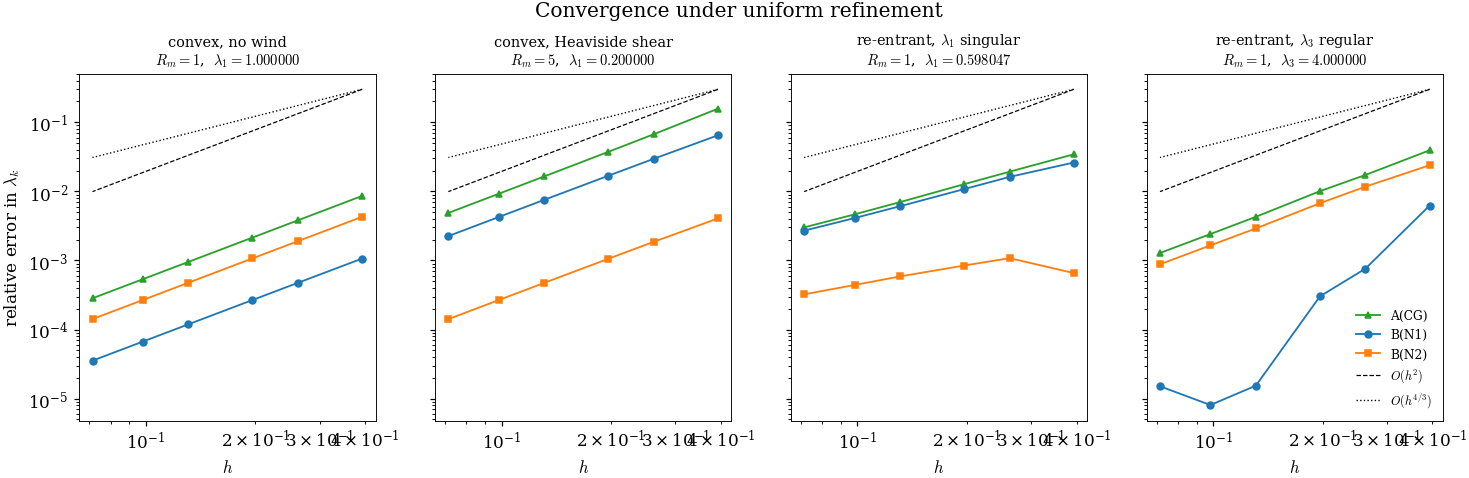

In [18]:
def convergence(domain, wind, Rm=1.0, k=1, levels=(8, 12, 16, 24, 32, 44),
                degree=1, **kw):
    """Relative error in the k-th eigenvalue versus mesh size, per formulation.

    `k` is 1-based.  On the square with a shear the reference is the exact family
    value nearest the computed eigenvalue; elsewhere it is the k-th reference
    eigenvalue of the domain.
    """
    target = EXACT[domain](k, Rm)[k - 1]
    out = {}
    for form in ("A(CG)", "B(N1)", "B(N2)"):
        hs, errs = [], []
        for N in levels:
            s = solve_induction(domain=domain, form=form, wind=wind, N=N, Rm=Rm,
                                degree=degree, n_eigs=k, left=False, **kw)
            hs.append(np.pi / N)
            errs.append(abs(s.values[k - 1].real - target) / abs(target))
        out[form] = (np.array(hs), np.array(errs))
    return out, target


STYLE = {"A(CG)": ("C2", "^"), "B(N1)": ("C0", "o"), "B(N2)": ("C1", "s")}

#: (domain, wind, Rm, eigenvalue index, extra solver kwargs, panel caption)
PANELS = [
    ("square", "W0", 1.0, 1, {}, "convex, no wind"),
    ("square", "W3", 5.0, 1, {}, "convex, Heaviside shear"),
    ("lshape", "W0", 1.0, 1, dict(tau=0.5), r"re-entrant, $\lambda_1$ singular"),
    ("lshape", "W0", 1.0, 3, dict(tau=0.5), r"re-entrant, $\lambda_3$ regular"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.1), sharey=True)
for ax, (domain, wind, Rm, k, kw, caption) in zip(axes, PANELS):
    curves, target = convergence(domain, wind, Rm=Rm, k=k, **kw)
    for form, (hs, errs) in curves.items():
        colour, marker = STYLE[form]
        ax.loglog(hs, np.maximum(errs, 1e-16), marker=marker, color=colour,
                  ms=4.5, lw=1.2, label=form)
    hs = curves["B(N1)"][0]
    ax.loglog(hs, 0.3 * (hs / hs[0]) ** 2, "k--", lw=0.8, label=r"$O(h^2)$")
    ax.loglog(hs, 0.3 * (hs / hs[0]) ** (4 / 3), "k:", lw=0.9, label=r"$O(h^{4/3})$")
    ax.set_xlabel(r"$h$")
    ax.set_title(f"{caption}\n$R_m={Rm:g}$,  "
                 f"$\\lambda_{{{k}}} = {target:.6f}$", fontsize=9.5)
axes[0].set_ylabel(r"relative error in $\lambda_k$")
axes[-1].legend(fontsize=8, frameon=False, loc="lower right")
fig.suptitle("Convergence under uniform refinement", y=1.04)
fig.savefig(FIGDIR / "convergence.pdf")
plt.show()

Four panels, three readings.

**Convex domain, panels 1–2.** All three formulations converge at the textbook $O(h^2)$
of a lowest-order method, with or without the wind. The wind costs accuracy — every curve
shifts up — but it does not cost *rate*.

**Re-entrant domain, panel 3.** `A(CG)` and `B(N1)` visibly flatten onto the $O(h^{4/3})$
guide line. That exponent is $2\times\tfrac{2}{3}$: the eigenvalue error is quadratic in
the eigenfunction error, and the eigenfunction only has $r^{2/3}$ regularity at the
corner. `B(N2)` sits an order of magnitude lower and its curve is ragged — its error has
already fallen to the level at which the mesh-to-mesh variation of independently generated
(non-nested) Netgen meshes dominates, so its slope at these resolutions is not yet
asymptotic. The honest statement is that panel 3 establishes the reduced rate for two of
the three formulations and shows the third to be well below the resolution of this
experiment.

**Re-entrant domain, panel 4.** The same meshes, the same elements, a different mode: for
$\lambda_3 = 4$, whose eigenfunction is *regular*, the full $O(h^2)$ comes back. This is
the cleanest available demonstration that the loss in panel 3 belongs to the solution's
regularity and not to the discretisation. The dip in the `B(N1)` curve near $h\approx0.1$
is an error **sign change**, not a failure: the computed $\lambda_3$ crosses 4 and the
absolute error passes through zero. Convergence plots of eigenvalue errors do this
routinely, which is why the surrounding slope, not a single point, is what should be read.

### 8.5 Eigenmodes

The natural picture differs by formulation, and it is worth being explicit about what is
being drawn:

* For **`A(CG)`** the eigenfunction *is* the potential, and since $B=\nabla\times A$ the
  **level sets of $A$ are the magnetic field lines**. A filled contour plot of the raw
  eigenfunction is therefore already a field-line diagram.
* For **`B(N1)`/`B(N2)`** the eigenfunction is the field itself. We colour by $|B|$ and
  overlay streamlines.

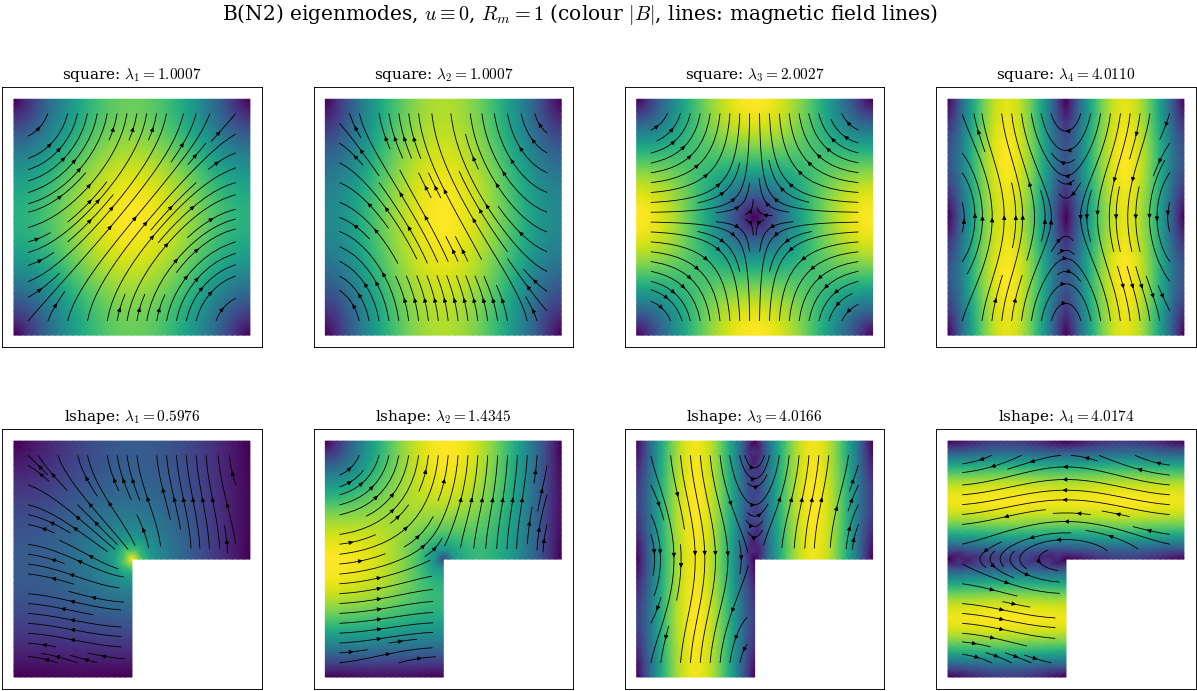

In [19]:
def normalise(f):
    """Scale a Function to unit maximum modulus.

    For a scalar the sign of the largest entry is fixed too, so that repeated
    solves of the same mode always come out the same way up; for a vector only
    the magnitude is normalised, the overall sign of an eigenvector being
    arbitrary in any case.
    """
    data = f.dat.data_ro
    mag = np.abs(data) if data.ndim == 1 else np.linalg.norm(data, axis=1)
    k = int(np.argmax(mag))
    scale = data[k] if data.ndim == 1 else mag[k]
    if abs(scale) > 0:
        f.dat.data[:] = f.dat.data_ro / scale
    return f


def plot_mode(ax, mode, form, mesh, part="right", n_stream=20, cmap="RdBu_r"):
    """Draw one eigenmode.  Complex modes are shown through their real part."""
    fr, fi = (mode.right if part == "right" else mode.left)
    f = fr if not mode.is_complex else fr        # real part of the eigenfunction

    if form == "A(CG)":
        A = normalise(Function(f.function_space()).assign(f))
        # A 98th-percentile colour limit rather than the maximum: adjoint modes
        # of an inflow/outflow problem carry a thin boundary layer whose peak
        # would otherwise wash out the whole interior.
        lim = float(np.percentile(np.abs(A.dat.data_ro), 98)) or 1.0
        handle = tripcolor(A, axes=ax, cmap=cmap, vmin=-lim, vmax=lim)
        # Field lines = level sets of A.
        B = as_cg_vector(as_vector([A.dx(1), -A.dx(0)]), mesh)
    else:
        v = f.subfunctions[0]                    # the H(curl) component
        B = normalise(as_cg_vector(v, mesh))
        mag = Function(FunctionSpace(mesh, "CG", 1)).project(sqrt(dot(B, B)))
        handle = tripcolor(mag, axes=ax, cmap="viridis")

    # NaNs from `sample_grid` mark points outside the domain; matplotlib's
    # streamplot stops integrating there, which is exactly the behaviour we want
    # around the L-shape's notch.
    X, Y, U, V = sample_grid(B, mesh, n=n_stream)
    ax.streamplot(X, Y, U, V, color="k", density=0.75, linewidth=0.55,
                  arrowsize=0.55)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    return handle


fig, axes = plt.subplots(2, 4, figsize=(14, 7.4))
for row, domain in enumerate(("square", "lshape")):
    kw = dict(tau=0.5) if domain == "lshape" else {}
    s = solve_induction(domain=domain, form="B(N2)", wind="W0", N=20, n_eigs=4, **kw)
    for col in range(4):
        plot_mode(axes[row, col], s.modes[col], "B(N2)", s.mesh)
        axes[row, col].set_title(rf"{domain}: $\lambda_{col+1} = "
                                 rf"{s.values[col].real:.4f}$", fontsize=10)
fig.suptitle(r"B(N2) eigenmodes, $u\equiv 0$, $R_m=1$ "
             r"(colour $|B|$, lines: magnetic field lines)", y=0.97)
fig.savefig(FIGDIR / "modes_W0.pdf")
plt.show()

The first L-shape mode is visibly concentrated at the re-entrant corner: that is the
$r^{2/3}$ singularity, and it is why $\lambda_1$ converges so slowly there. The higher
L-shape modes are smooth away from the corner and converge at the full rate.

### 8.6 Non-normality: right versus left eigenvectors

With the shear switched on, the operator is no longer self-adjoint and the right and left
eigenvectors separate. Physically, the right eigenvector is the shape a decaying field
settles into; the left eigenvector is the **receptivity** — where the operator is most
sensitive to a perturbation. Advection sweeps the two apart.

Before drawing them, two numerical checks on $\kappa$, which is only worth reporting if
it behaves like a property of the operator.

In [20]:
# Check 1: for a self-adjoint problem kappa must be exactly 1 -- but only where
# the eigenvalue is simple.  On the square, lambda = 1, 4, 5, ... are all double,
# and there the two solves may return different bases of the eigenspace, so the
# overlap is arbitrary.  lambda_3 = 2 is simple and is the meaningful test.
check = {form: solve_induction(domain="square", form=form, wind="W0", N=16,
                               Rm=1.0, n_eigs=4, left=True)
         for form in ("A(CG)", "B(N1)", "B(N2)")}
print("kappa for u = 0 (lambda = 1, 1, 2, 4; only lambda_3 = 2 is simple)")
for form, spectrum in check.items():
    print(f"  {form:6s}", np.round([m.condition for m in spectrum.modes], 6))

# Check 2: in the M-norm kappa is mesh-independent.  The adjoint boundary layer
# has width O(1/Rm) = 0.05 here, so A(CG) only settles once h resolves it.
print("\nkappa(lambda_1) under refinement, W3, Rm = 20")
for N in (16, 24, 32, 48, 64):
    row = {form: solve_induction(domain="square", form=form, wind="W3", N=N,
                                 Rm=20.0, n_eigs=1).modes[0].condition
           for form in ("A(CG)", "B(N2)")}
    print(f"  N = {N:3d}  h = {np.pi/N:.4f}   "
          + "   ".join(f"{f}: {k:7.3f}" for f, k in row.items()))

kappa for u = 0 (lambda = 1, 1, 2, 4; only lambda_3 = 2 is simple)
  A(CG)  [1.000022 1.000046 1.       2.434552]
  B(N1)  [1.208226 1.002412 1.       9.102057]
  B(N2)  [1.272157 3.074632 1.       1.302787]

kappa(lambda_1) under refinement, W3, Rm = 20


  N =  16  h = 0.1963   A(CG):   8.002   B(N2):   2.037


  N =  24  h = 0.1309   A(CG):   6.926   B(N2):   2.034


  N =  32  h = 0.0982   A(CG):   6.489   B(N2):   2.033


  N =  48  h = 0.0654   A(CG):   6.146   B(N2):   2.032


  N =  64  h = 0.0491   A(CG):   6.018   B(N2):   2.031


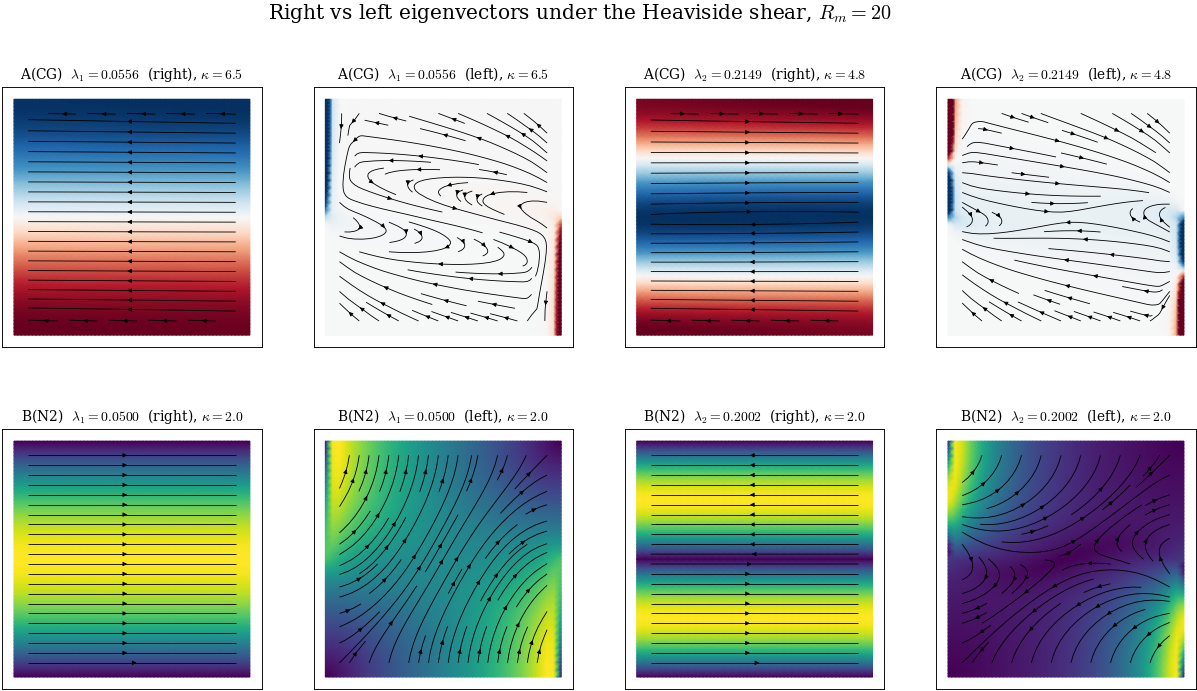

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7.4))
runs = [("A(CG)", 20.0), ("B(N2)", 20.0)]

for row, (form, Rm) in enumerate(runs):
    s = solve_induction(domain="square", form=form, wind="W3", N=32, Rm=Rm, n_eigs=2)
    for k in range(2):
        for j, side in enumerate(("right", "left")):
            ax = axes[row, 2 * k + j]
            plot_mode(ax, s.modes[k], form, s.mesh, part=side)
            ax.set_title(rf"{form}  $\lambda_{k+1}={s.values[k].real:.4f}$"
                         rf"  ({side}), $\kappa={s.modes[k].condition:.1f}$",
                         fontsize=9)
fig.suptitle(r"Right vs left eigenvectors under the Heaviside shear, $R_m = 20$", y=0.97)
fig.savefig(FIGDIR / "left_right.pdf")
plt.show()

Both checks pass, and they carry the section between them. On the one **simple**
eigenvalue of the self-adjoint problem, $\lambda_3 = 2$, all three formulations return
$\kappa = 1.000000$. The two double eigenvalues return whatever the two solves' choices
of basis happen to overlap to — sometimes near $1$, sometimes not — exactly as warned in
Section 6.3. And in the $M$-norm $\kappa$ is flat under refinement: `B(N2)` moves only
from $2.037$ to $2.031$ across a four-fold change in $h$. (Computed in the Euclidean
coefficient norm instead, the same quantity climbs from $2.3$ to $3.9$ over that range,
and keeps climbing — the norm, not the operator, doing the talking.)

The figure shows the two rows failing in quite different ways.

For **`A(CG)`** the right eigenvector is a smooth $y$-dependent profile with horizontal
field lines, while the left eigenvector is essentially zero through the interior and
compressed into two strips about one element wide against $x=0$ and $x=\pi$. That is the
boundary term $\oint(u\cdot n)\,A\,z$ flagged in Section 3: because `W3` blows through
the vertical walls, the adjoint problem carries a layer of width
$O(\varepsilon/\lVert u\rVert) = O(1/R_m)$. At $R_m=20$ that is $0.05$ against
$h = \pi/32 \approx 0.098$ — thinner than one element. Check 2 shows $\kappa$ falling
from $8.0$ to $6.0$ as refinement begins to resolve it, and it is the same
under-resolution that makes `A(CG)` the least accurate formulation in the Section 8.3
table.

For **`B(N2)`** the left eigenvector also leans towards the vertical walls, but it is
spread over many elements rather than compressed into one, and $\kappa\approx 2.03$ is
already converged at the coarsest level tested. The mixed formulation never integrates
its induction term by parts, so its adjoint acquires no boundary term of this kind.

The table below sweeps $\kappa$ over the first five modes. Three things to take from it:

* The magnitudes are modest — between $1.5$ and $25$. At these $R_m$ the operator is
  mildly non-normal, not catastrophically so: to first order an operator perturbation of
  size $\delta$ moves an eigenvalue by at most about $\kappa\,\delta$.
* **`B(N1)` and `B(N2)` agree to a few percent in every entry.** They share the same mass
  matrix and converge to the same operator, so this is one more cross-formulation check —
  and this time on a quantity that involves the adjoint, which nothing earlier tested.
* **`A(CG)` tracks them at $R_m=1$** ($5.94$ against $5.45$ and $5.51$) and separates as
  $R_m$ grows, by close to the amount its unresolved adjoint layer costs.

Complex conjugate pairs necessarily share a condition number, which is why entries such as
$\kappa_3 = \kappa_4$ repeat exactly.

In [22]:
# N = 32 keeps the cell Peclet number below 1 for every Rm in this sweep
# (see Section 9); Rm = 20 is the largest value this mesh can carry honestly.
rows = []
for Rm in (1.0, 2.0, 5.0, 10.0, 20.0):
    for form in ("A(CG)", "B(N1)", "B(N2)"):
        s = solve_induction(domain="square", form=form, wind="W3", N=32,
                            Rm=Rm, n_eigs=5)
        rows.append(dict(Rm=Rm, form=form,
                         **{rf"$\kappa_{k+1}$": s.modes[k].condition
                            for k in range(5)}))

df_kappa = pd.DataFrame(rows).set_index(["Rm", "form"])
fmt_table(df_kappa, default="{:.4g}",
          caption=r"Condition numbers $\kappa(\lambda_k)$ of the first five modes, "
                  r"in the $M$-norm (square, W3, $N = 32$)")

**Condition numbers $\kappa(\lambda_k)$ of the first five modes, in the $M$-norm (square, W3, $N = 32$)**

$\kappa_1$ $\kappa_2$ $\kappa_3$ $\kappa_4$ $\kappa_5$
Rm   form                                                        
1.0  A(CG)      5.937      5.986      1.616      9.061      8.925
     B(N1)      5.449      5.477      1.492      9.405      9.189
     B(N2)      5.509      5.536      1.492      9.382      9.163
2.0  A(CG)      3.984      4.285      14.11      14.11      21.18
     B(N1)       3.33      3.502      14.96      14.96      24.03
     B(N2)      3.349       3.52      14.05      14.05      22.17
5.0  A(CG)      3.743      4.837      3.594      7.267      7.267
     B(N1)      2.356      3.451       2.87      5.045      5.045
     B(N2)      2.367      3.448      2.887      4.987      4.987
10.0 A(CG)      4.588      3.439      16.99      20.36      8.191
     B(N1)      2.117      2.111      10.87      13.86      5.917
     B(N2)      2.129      2.127      12.33      15.37      5.742
20.0 A(CG)      6.489      4.839      23.78      23.78      7.535
     B(N1)      2.015      2.011      6.355      8.191      3.697
     B(N2)      2.033      2.032      8.394      10.21      3.949

### 8.7 The spectrum in the complex plane

The final view collects everything. As $R_m$ grows the diffusive spectrum
$\{(m^2+n^2)/R_m\}$ contracts towards the origin; the exact family $n^2/R_m$ stays
pinned on the real axis, marked with crosses; and the modes that *do* feel the shear peel
off into complex conjugate pairs — travelling waves riding the shear layer — whose
imaginary parts grow relative to their real parts as advection takes over from
diffusion.

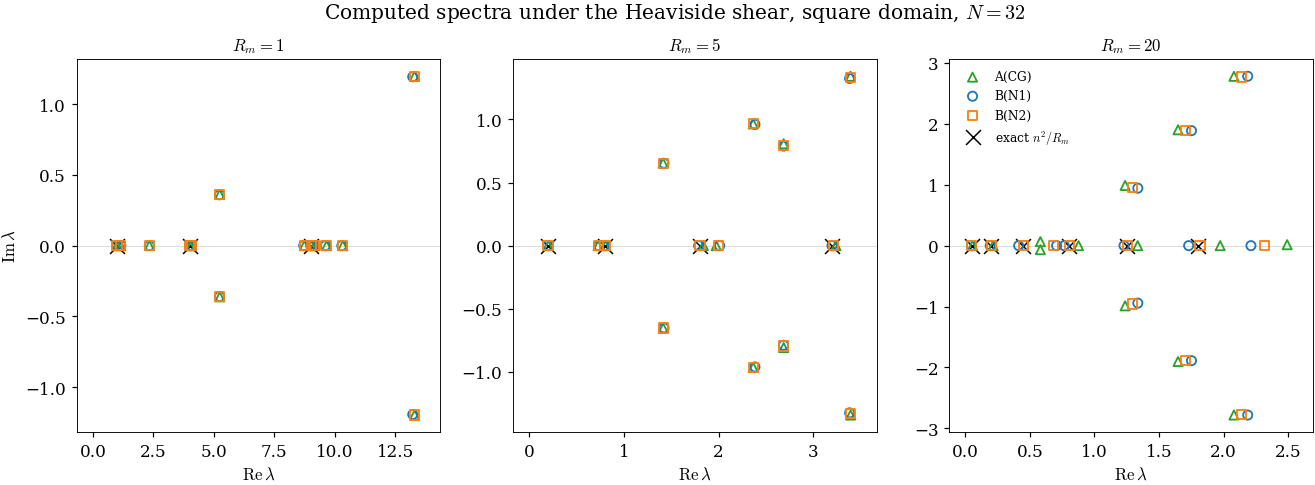

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
for ax, Rm in zip(axes, (1.0, 5.0, 20.0)):
    span = 0.0
    for form in ("A(CG)", "B(N1)", "B(N2)"):
        colour, marker = STYLE[form]
        s = solve_induction(domain="square", form=form, wind="W3", N=32, Rm=Rm,
                            n_eigs=14, nev=44, left=False)
        ax.scatter(s.values.real, s.values.imag, s=36, marker=marker,
                   facecolors="none", edgecolors=colour, linewidths=1.2, label=form)
        span = max(span, s.values.real.max())
    exact = exact_shear_family(6, Rm)
    exact = exact[exact <= span]        # only the family members actually resolved
    ax.scatter(exact, np.zeros_like(exact), s=95, marker="x", color="k",
               linewidths=1.0, label=r"exact $n^2/R_m$", zorder=0)
    ax.axhline(0, color="0.85", lw=0.6, zorder=-1)
    ax.set_title(rf"$R_m = {Rm:g}$"); ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
    ax.set_xlim(-0.05 * span, 1.08 * span)
axes[0].set_ylabel(r"$\mathrm{Im}\,\lambda$")
axes[-1].legend(fontsize=8, frameon=False, loc="upper left")
fig.suptitle("Computed spectra under the Heaviside shear, square domain, $N=32$", y=1.0)
fig.savefig(FIGDIR / "complex_plane.pdf")
plt.show()

At $R_m = 1$ and $R_m = 5$ the three formulations sit on top of one another: the markers
overlap everywhere, and the crosses fall on them. At $R_m = 20$ they visibly separate
along the real axis — the same accuracy ordering as the Section 8.3 table, now visible in
one glance across a dozen modes at once. The imaginary parts, by contrast, still agree
closely: the travelling-wave frequencies are far easier to capture than the decay rates.

### 8.8 The full selection grid

Finally, the execution loop as advertised: pick a mesh, a formulation and a wind, and
sweep.

In [24]:
records = []
for domain in DOMAINS:
    for wind in ("W0", "W2", "W3"):
        for form in ("A(CG)", "B(N1)", "B(N2)"):
            kw = dict(tau=0.5) if domain == "lshape" else {}
            s = solve_induction(domain=domain, form=form, wind=wind, N=20,
                                Rm=5.0, n_eigs=3, **kw)
            records.append(dict(
                domain=domain, wind=wind, form=form, size=s.pencil.size,
                **{f"$\\lambda_{i+1}$": s.values[i] for i in range(3)},
                kappa=s.modes[0].condition))

grid = pd.DataFrame(records).set_index(["domain", "wind", "form"])
fmt_table(grid, default="{:.5f}", rules=[("size", "{:.0f}"), ("kappa", "{:.3g}")],
          caption=r"Every combination at $R_m = 5$, $N = 20$, degree 1 "
                  r"($\kappa$ is undefined for the self-adjoint case W0)")

**Every combination at $R_m = 5$, $N = 20$, degree 1 ($\kappa$ is undefined for the self-adjoint case W0)**

size $\lambda_1$ $\lambda_2$       $\lambda_3$ kappa
domain wind form                                                       
square W0   A(CG)   842     0.20027     0.20027           0.40069    --
            B(N1)  3281     0.20003     0.20003           0.39973    --
            B(N2)  8161     0.20014     0.20014           0.40055    --
       W2   A(CG)   842     0.19625     0.33241           0.83971  1.87
            B(N1)  3281     0.20105     0.33340           0.83021  1.17
            B(N2)  8161     0.20014     0.33400           0.83542  1.17
       W3   A(CG)   842     0.20475     0.72384           0.81437  3.83
            B(N1)  3281     0.19784     0.73602           0.79552  2.34
            B(N2)  8161     0.20014     0.72988           0.80218  2.37
lshape W0   A(CG)   388     0.12069     0.28707           0.80496    --
            B(N1)  1465     0.11867     0.28647           0.79970    --
            B(N2)  3621     0.11952     0.28690           0.80332    --
       W2   A(CG)   388     0.24711     0.70959  1.18977+0.02711i   1.7
            B(N1)  1465     0.25107     0.70599           1.15421  1.35
            B(N2)  3621     0.25055     0.71134  1.18148+0.02669i  1.35
       W3   A(CG)   388     0.21262     0.81155           1.39908  2.66
            B(N1)  1465     0.20212     0.79387           1.41028  1.32
            B(N2)  3621     0.20677     0.80378           1.40283  1.33

<a id="9"></a>
## 9. Notes, caveats and extensions

**The cell Péclet number.** Nothing here is stabilised, deliberately: SUPG and friends
perturb the operator, and this laboratory exists to measure the operator. The price is
that Galerkin advection–diffusion is only reliable while the cell Péclet number
$\mathrm{Pe}_h = h\,\lVert u\rVert R_m / 2$ stays near or below 1. On the square with
$L=\pi$ that means

$$
N \;\gtrsim\; \frac{\pi\,R_m}{2},
$$

so $R_m = 20$ wants $N \gtrsim 31$ and $R_m = 100$ wants $N \gtrsim 157$. Running past
that produces eigenvalues with negative real part that look like dynamo growth and are
nothing of the kind. Every figure above respects the bound.

**Choosing $\tau$.** The shift has to track the spectrum. The default $\tau = 0.95/R_m$
works because the leading decay rate scales like $1/R_m$; on the L-shape, whose first
eigenvalue is $0.598/R_m$, `tau=0.5/Rm` is a better centre and is passed explicitly
throughout. If a run returns eigenvalues far from where you expect, suspect $\tau$ before
suspecting the discretisation: `eps_target_magnitude` returns the `nev` eigenvalues
nearest $\tau$, and sorting *those* by real part is not the same as sorting the whole
spectrum.

**Degree.** Every result above is lowest order (`degree=1`). Passing `degree=2` gives
$\mathrm{N1curl}_2 \times \mathrm{CG}_2$ and $\mathrm{N2curl}_2 \times \mathrm{CG}_3$, and
recovers the optimal rate on the square; on the L-shape it does not help the singular
mode, because the obstruction is the regularity of the solution, not the approximation
power of the space. That contrast is worth reproducing.

**Parallelism.** `to_function` slices the local part of a `Vec`, and `to_scipy`
materialises the whole matrix; both are serial conveniences. The assembly, the
factorisation and the eigensolve are all parallel-ready — only the post-processing needs
rewriting for MPI.

**Where to go next.** Three natural extensions from here: a $p$-refinement study to
separate approximation error from regularity; a non-simply-connected domain (an annulus),
where the harmonic field is a genuine kernel of the curl and $\lambda = 0$ returns as a
real eigenvalue that must be handled rather than filtered; and pseudospectra, which turn
the condition numbers of Section 8.6 into a picture of exactly how far the spectrum can
be moved by a perturbation of a given size.

In [25]:
print("figures written to", FIGDIR.resolve())
for p in sorted(FIGDIR.glob("*.pdf")):
    print("  ", p.name)

figures written to /Users/lourenco/Desktop/Dissertation_Firedrake/Experiments/final/figures
   complex_plane.pdf
   convergence.pdf
   left_right.pdf
   meshes.pdf
   modes_W0.pdf
   winds.pdf
